## Predicting Total Price from Customer Sales Behaviours

**Dataset:** Customer_sales_behaviours.csv  
**Model:** Linear Regression  
**Submitted By:** Laxmi Karki (ACE081BCT042) and Kritika Rai (ACE081BCT042)

## Problem Definition

**Objective:**  
1. To analyze customer sales behaviour data and understand how different features such as age, product type, quantity, rating, and unit price influence the total purchase price.

2. To build a Linear Regression model that can predict the Total Price of a customer purchase using relevant input features from the dataset.

3. To evaluate the performance of the model using metrics such as Mean Squared Error (MSE) and R² score to determine how accurately the model predicts customer spending.


**Why Linear Regression?**  
We chose Linear Regression because our target variable (Total Price) is a continuous numerical value. Linear Regression is good for understanding how each feature affects the predicted output, and it is one of the simplest and most interpretable models to start with.

In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

## Data Collection / Loading the Datasets

In [ ]:
# Loading the dataset
df = pd.read_csv('Customer_sales_behaviours.csv')

print('Shape of dataset:', df.shape)
df.head()

Shape of dataset: (20000, 16)


,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  object 
 3   Loyalty Member     20000 non-null  object 
 4   Product Type       20000 non-null  object 
 5   SKU                20000 non-null  object 
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  object 
 8   Payment Method     20000 non-null  object 
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  object 
 13  Shipping Type      20000 non-null  object 
 14  Add-ons Purchased  15132 non-null  object 
 15  Add-on Total       20000 non-null  float64
dtypes: float64(3), int64(4

,Customer ID,Age,Rating,Total Price,Unit Price,Quantity,Add-on Total
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10483.526550,48.994100,3.093950,3180.133418,578.631867,5.485550,62.244848
std,5631.732525,18.038745,1.223764,2544.978675,312.274076,2.870854,58.058431
min,1000.000000,18.000000,1.000000,20.750000,20.750000,1.000000,0.000000
25%,5478.000000,33.000000,2.000000,1139.680000,361.180000,3.000000,7.615000
50%,10499.500000,49.000000,3.000000,2534.490000,463.960000,5.000000,51.700000
75%,15504.000000,65.000000,4.000000,4639.600000,791.190000,8.000000,93.842500
max,19998.000000,80.000000,5.000000,11396.800000,1139.680000,10.000000,292.770000


## EDA & Preprocessing

In [ ]:
#checking missing values
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
Customer ID             0
Age                     0
Gender                  1
Loyalty Member          0
Product Type            0
SKU                     0
Rating                  0
Order Status            0
Payment Method          0
Total Price             0
Unit Price              0
Quantity                0
Purchase Date           0
Shipping Type           0
Add-ons Purchased    4868
Add-on Total            0
dtype: int64


In [ ]:
#cleaning data, replacing add-ons with none and dropping the row that has one missing value of gender
df['Add-ons Purchased'] = df['Add-ons Purchased'].fillna('None')

df = df.dropna(subset=['Gender'])

print('Missing values after cleaning:')
print(df.isnull().sum())
print('\nNew shape:', df.shape)

Missing values after cleaning:
Customer ID          0
Age                  0
Gender               0
Loyalty Member       0
Product Type         0
SKU                  0
Rating               0
Order Status         0
Payment Method       0
Total Price          0
Unit Price           0
Quantity             0
Purchase Date        0
Shipping Type        0
Add-ons Purchased    0
Add-on Total         0
dtype: int64

New shape: (19999, 16)


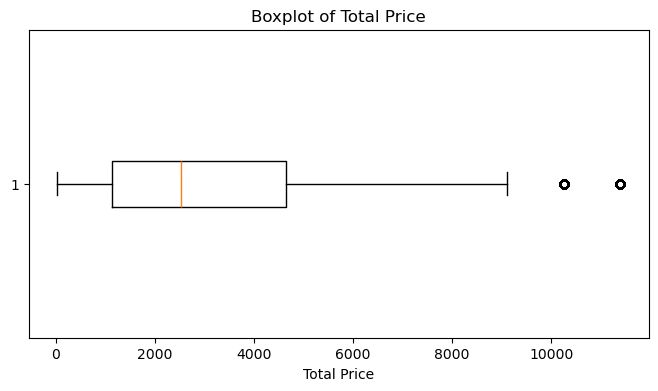

In [23]:
# Checking for outliers
# Checking for outliers in Total Price
plt.figure(figsize=(8, 4))
plt.boxplot(df['Total Price'], vert=False)
plt.title('Boxplot of Total Price')
plt.xlabel('Total Price')
plt.show()

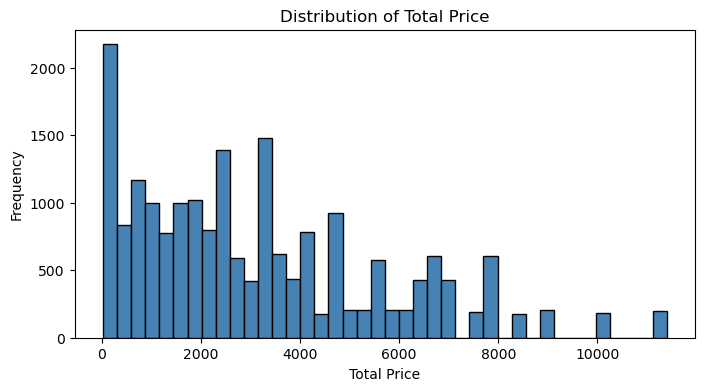

In [24]:
# Distribution of Total Price
plt.figure(figsize=(8, 4))
plt.hist(df['Total Price'], bins=40, color='steelblue', edgecolor='black')
plt.title('Distribution of Total Price')
plt.xlabel('Total Price')
plt.ylabel('Frequency')
plt.show()

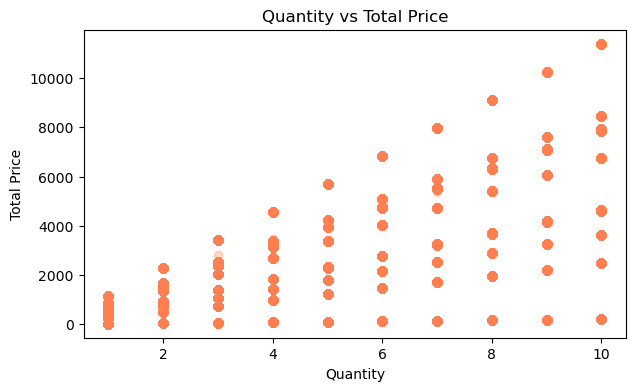

In [25]:
# Total Price vs Quantity scatter
plt.figure(figsize=(7, 4))
plt.scatter(df['Quantity'], df['Total Price'], alpha=0.3, color='coral')
plt.title('Quantity vs Total Price')
plt.xlabel('Quantity')
plt.ylabel('Total Price')
plt.show()

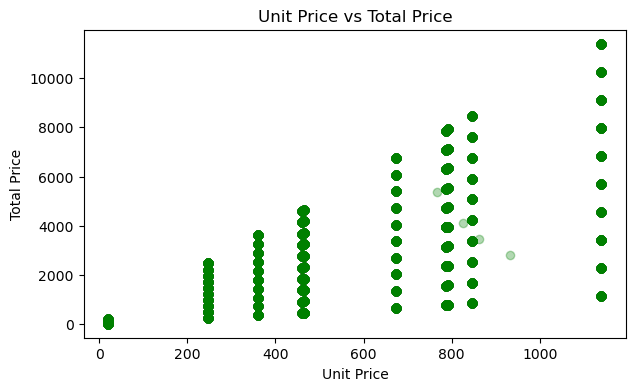

In [26]:
# Total Price vs Unit Price scatter
plt.figure(figsize=(7, 4))
plt.scatter(df['Unit Price'], df['Total Price'], alpha=0.3, color='green')
plt.title('Unit Price vs Total Price')
plt.xlabel('Unit Price')
plt.ylabel('Total Price')
plt.show()

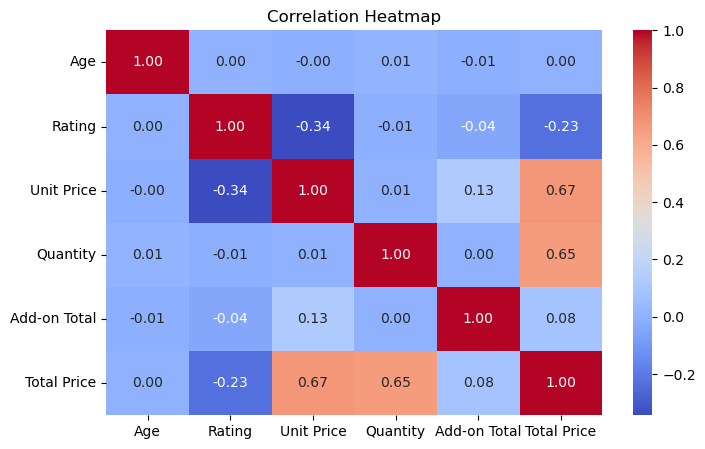

In [27]:
# Correlation heatmap (numerical columns only)
plt.figure(figsize=(8, 5))
num_cols = df[['Age', 'Rating', 'Unit Price', 'Quantity', 'Add-on Total', 'Total Price']]
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [28]:
# Encoding categorical columns
le = LabelEncoder()

cat_cols = ['Gender', 'Loyalty Member', 'Product Type', 'Shipping Type', 'Order Status', 'Payment Method']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('Encoding done!')
df[['Gender', 'Loyalty Member', 'Product Type', 'Shipping Type']].head()

Encoding done!


,Gender,Loyalty Member,Product Type,Shipping Type
0,1,0,2,4
1,1,0,4,2
2,1,0,1,1
3,1,1,2,2
4,1,1,2,1


In [29]:
# Selecting features to use
features = ['Age', 'Gender', 'Loyalty Member', 'Product Type', 'Rating',
            'Unit Price', 'Quantity', 'Shipping Type', 'Add-on Total']

X = df[features]
y = df['Total Price']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (19999, 9)
Target shape: (19999,)


In [30]:
# Splitting data into 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (15999, 9)
Testing set size: (4000, 9)


## Model Building
Training a **Linear Regression** model using sklearn.

In [31]:
# Creating and training the model
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully!')

Model trained successfully!


In [32]:
# Checking the coefficients (weights for each feature)
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
print('Model Coefficients:')
print(coef_df)
print('\nIntercept:', model.intercept_)

Model Coefficients:
          Feature  Coefficient
0             Age     0.184165
1          Gender   -17.501354
2  Loyalty Member    -3.839666
3    Product Type    -1.658519
4          Rating    12.254215
5      Unit Price     5.477625
6        Quantity   576.803122
7   Shipping Type    -5.344913
8    Add-on Total    -0.109764

Intercept: -3166.094271712988


##  Model Evaluation

Checking how well the model is doing on the test data using **R², MSE, and RMSE**.

In [33]:
# Making predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print('R2 Score :', round(r2, 4))
print('MSE      :', round(mse, 2))
print('RMSE     :', round(rmse, 2))

R2 Score : 0.8742
MSE      : 797064.97
RMSE     : 892.78


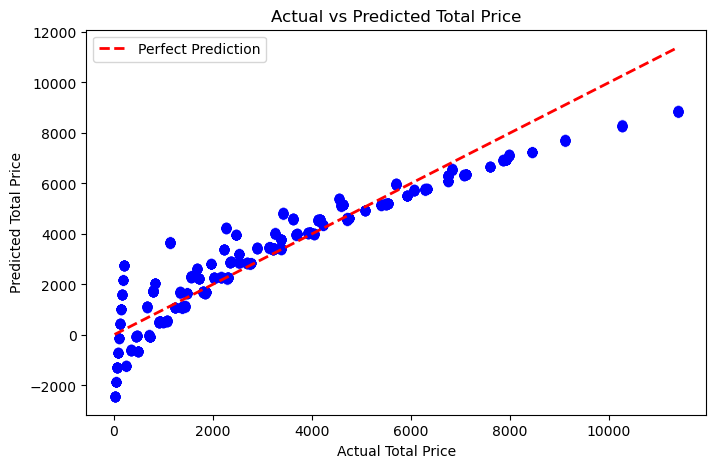

In [34]:
# Visualizing Actual vs Predicted values
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Total Price')
plt.ylabel('Predicted Total Price')
plt.title('Actual vs Predicted Total Price')
plt.legend()
plt.show()

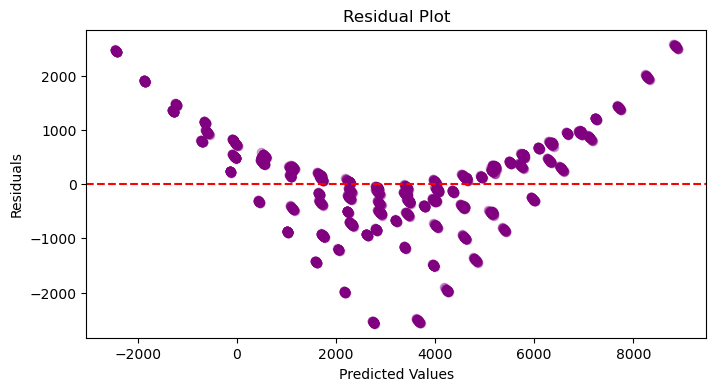

In [35]:
# Residual plot (difference between actual and predicted)
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.scatter(y_pred, residuals, alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

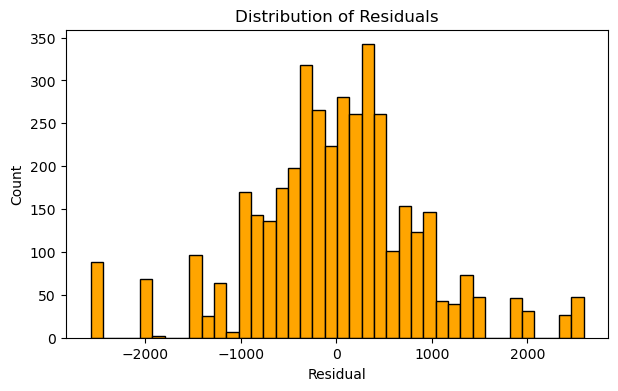

In [36]:
# Distribution of residuals
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=40, color='orange', edgecolor='black')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.show()

## Interpretation & Conclusion

### Interpretation

The analysis was performed to understand how different customer and product related features influence the **Total Price** of a purchase and to evaluate how effectively a **Linear Regression model** can predict this value.

From the **correlation analysis**, it was observed that **Unit Price** and **Quantity** have the strongest positive relationship with **Total Price**. This relationship is logical because the total purchase cost is directly influenced by how many items are bought and the price of each item. The **Add-on Total** also contributes to the final price, though its effect is comparatively smaller.

The **regression coefficients** further confirm these observations. Features such as **Unit Price** and **Quantity** have the highest coefficient values, indicating that they play the most significant role in determining the predicted total price. Other variables such as **Age** and **Rating** have relatively smaller effects on the prediction.

The **Actual vs Predicted plot** shows that most predicted values lie close to the diagonal reference line. This indicates that the model is able to capture the overall trend of the data and produce predictions that are reasonably close to the actual values.

Additionally, the **residual distribution** appears to be centered around zero, suggesting that the model errors are randomly distributed and there is no major systematic bias in the predictions.

### Conclusion

In this project, a **Linear Regression model** was successfully developed to predict the **Total Price** of customer purchases based on several input features. The evaluation metrics such as **R² Score, Mean Squared Error (MSE), and Root Mean Squared Error (RMSE)** indicate that the model performs reasonably well in explaining the variation in the target variable.

The results show that **Unit Price and Quantity are the most influential factors affecting the total purchase cost**, which aligns with practical expectations in sales data. Overall, the model demonstrates that linear regression is an effective and interpretable approach for this type of prediction problem.

For future improvements, the model could be enhanced by performing **feature engineering**, handling possible outliers, or experimenting with more advanced machine learning algorithms such as **Random Forest or Gradient Boosting** to potentially achieve higher prediction accuracy.